# Flyforecast: baseline ML solution

[flyforecast.ru](https://flyforecast.ru) - сервис для оценки вероятности вылета через аэропорт Менделеево на острове Кунашир (Сахалинская область). Пользователь выбирает дату, а сервис говорит полетит самолет или нет, возвращая вероятностную оценку и объяснение риска на основе исторических статусов рейсов, сезонности и погодных факторов: видимости, низкой облачности, влажности, ветра и признаков тумана. Это инструмент поддержки планирования поездки в регион, где отмены и переносы часто зависят от погоды.

Задача: бинарная классификация дня рейса через Менделеево: `completed` против `cancelled`.

Baseline для сравнения - текущая production-эвристика сервиса `mvp-baseline-002`. Она кодирует доменную логику: историческую вероятность похожих дат, сезонность внутри месяца и погодную поправку для ближнего горизонта.

Данные ожидаются в файле `data/processed/training_dataset_v1.csv`. Этот файл не хранится в git, потому что проектные датасеты лежат в `data/` и исключены через `.gitignore`.

In [1]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.calibration import calibration_curve
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    brier_score_loss,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")

DATA_PATH = Path("../data/processed/training_dataset_v1.csv")
if not DATA_PATH.exists():
    DATA_PATH = Path("data/processed/training_dataset_v1.csv")

DATA_PATH


WindowsPath('data/processed/training_dataset_v1.csv')

## 1. Загрузка и первичная очистка данных

В датасете одна строка соответствует календарному дню. Целевая переменная `is_flight_completed` равна:

- `1` - рейс выполнен;
- `0` - рейс отменен.

Для baseline-решения используем хронологическое разбиение, чтобы модель не училась на будущих наблюдениях относительно валидации и теста.

In [2]:
df = pd.read_csv(DATA_PATH, parse_dates=["date"])
df = df.sort_values("date").reset_index(drop=True)

print(f"Rows: {len(df):,}")
print(f"Columns: {df.shape[1]:,}")
print(f"Date range: {df['date'].min().date()} .. {df['date'].max().date()}")
print(f"Training data version: {df.get('training_data_version', pd.Series(['unknown'])).iloc[0]}")

df.head()

Rows: 761
Columns: 106
Date range: 2017-12-13 .. 2026-05-26
Training data version: training-v3-openmeteo-historical-forecast-visibility-2026-05-28


,date,status,is_flight_completed,label_confidence,reason_class,message_count,transport_types,event_date_sources,year,month,...,prev_3_cancelled_count,prev_7_cancelled_count,prev_14_completed_rate,prev_30_completed_rate,same_month_past_completed_rate,same_decade_past_completed_rate,days_since_last_cancelled,cancelled_streak_before,completed_streak_before,training_data_version
0,2017-12-13,cancelled,0,high,unknown_cancel_reason,1,airplane,historical_sources_v2,2017,12,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,training-v3-openmeteo-historical-forecast-visi...
1,2017-12-26,cancelled,0,high,weather,1,airplane,manual_review_v3,2017,12,...,1.0,1.0,NaN,NaN,0.0,NaN,13.0,1,0,training-v3-openmeteo-historical-forecast-visi...
2,2018-01-10,cancelled,0,high,unknown_delay_reason;unknown_cancel_reason,4,airplane,historical_sources_v2,2018,1,...,2.0,2.0,NaN,NaN,NaN,NaN,15.0,2,0,training-v3-openmeteo-historical-forecast-visi...
3,2018-01-11,cancelled,0,high,unknown_cancel_reason,1,airplane,historical_sources_v2,2018,1,...,3.0,3.0,0.0,NaN,0.0,NaN,1.0,3,0,training-v3-openmeteo-historical-forecast-visi...
4,2018-01-23,cancelled,0,high,unknown_cancel_reason,1,airplane,historical_sources_v2,2018,1,...,3.0,4.0,0.0,NaN,0.0,NaN,12.0,4,0,training-v3-openmeteo-historical-forecast-visi...


In [3]:
target = "is_flight_completed"

print("Target distribution:")
display(df[target].value_counts().rename(index={1: "completed", 0: "cancelled"}).to_frame("days"))

display(df[["date", "status", target, "mendeleyevo_visibility_min", "mendeleyevo_fog_low_cloud_risk_level"]].tail(10))

Target distribution:


,days
is_flight_completed,
completed,411
cancelled,350


,date,status,is_flight_completed,mendeleyevo_visibility_min,mendeleyevo_fog_low_cloud_risk_level
751,2026-05-13,completed,1,560.0,medium
752,2026-05-14,completed,1,2860.0,medium
753,2026-05-15,completed,1,2280.0,low
754,2026-05-16,completed,1,800.0,medium
755,2026-05-17,completed,1,580.0,high
756,2026-05-18,completed,1,7620.0,medium
757,2026-05-19,cancelled,0,720.0,high
758,2026-05-20,completed,1,640.0,high
759,2026-05-25,cancelled,0,160.0,high
760,2026-05-26,cancelled,0,160.0,high


In [4]:
missing = (
    df.isna()
    .mean()
    .sort_values(ascending=False)
    .rename("missing_share")
    .to_frame()
)
missing.head(20)

,missing_share
khomutovo_visibility_min,0.413929
khomutovo_visibility_mean,0.413929
mendeleyevo_visibility_min,0.413929
mendeleyevo_visibility_mean,0.413929
same_decade_past_completed_rate,0.048620
same_month_past_completed_rate,0.015769
prev_30_completed_rate,0.006570
prev_14_completed_rate,0.003942
days_since_last_cancelled,0.001314
prev_1_completed,0.001314


### Очистка и защита от утечек

Из признаков исключаем поля, которые либо являются целевой переменной, либо описывают факт уже после события: `status`, `reason_class`, `label_confidence`, текстовые источники события и версии данных.

Для признаков видимости добавляем отдельные индикаторы пропусков. Это важно: историческая видимость есть не для всего периода, и сам факт отсутствия видимости в старой части данных тоже должен быть обработан явно.

In [5]:
leakage_cols = [
    "date",
    "status",
    target,
    "label_confidence",
    "reason_class",
    "message_count",
    "transport_types",
    "event_date_sources",
    "data_version",
    "training_data_version",
]

X = df.drop(columns=[col for col in leakage_cols if col in df.columns]).copy()
y = df[target].astype(int)

visibility_cols = [col for col in X.columns if "visibility" in col]
for col in visibility_cols:
    X[f"{col}_missing"] = X[col].isna().astype(int)

n_rows = len(df)
train_end = int(n_rows * 0.70)
valid_end = int(n_rows * 0.85)

split_labels = pd.Series(index=df.index, dtype="object")
split_labels.iloc[:train_end] = "train"
split_labels.iloc[train_end:valid_end] = "valid"
split_labels.iloc[valid_end:] = "test"

X_train = X.iloc[:train_end].copy()
y_train = y.iloc[:train_end].copy()
X_valid = X.iloc[train_end:valid_end].copy()
y_valid = y.iloc[train_end:valid_end].copy()
X_test = X.iloc[valid_end:].copy()
y_test = y.iloc[valid_end:].copy()

all_missing_train_cols = [col for col in X_train.columns if X_train[col].isna().all()]
if all_missing_train_cols:
    X_train = X_train.drop(columns=all_missing_train_cols)
    X_valid = X_valid.drop(columns=all_missing_train_cols)
    X_test = X_test.drop(columns=all_missing_train_cols)

split_summary = pd.DataFrame(
    [
        ["train", len(X_train), df.loc[0, "date"].date(), df.loc[train_end - 1, "date"].date(), int(y_train.sum()), int((1 - y_train).sum()), y_train.mean()],
        ["valid", len(X_valid), df.loc[train_end, "date"].date(), df.loc[valid_end - 1, "date"].date(), int(y_valid.sum()), int((1 - y_valid).sum()), y_valid.mean()],
        ["test", len(X_test), df.loc[valid_end, "date"].date(), df.loc[n_rows - 1, "date"].date(), int(y_test.sum()), int((1 - y_test).sum()), y_test.mean()],
    ],
    columns=["split", "rows", "date_from", "date_to", "completed_days", "cancelled_days", "completion_rate"],
)

print("Dropped all-missing-in-train columns:", all_missing_train_cols)
display(split_summary)


Dropped all-missing-in-train columns: []


,split,rows,date_from,date_to,completed_days,cancelled_days,completion_rate
0,train,532,2017-12-13,2022-07-01,353,179,0.663534
1,valid,114,2022-07-06,2023-12-30,30,84,0.263158
2,test,115,2024-01-10,2026-05-26,28,87,0.243478


### Проверка временного сдвига target

После хронологического split отдельно проверяем drift целевой переменной и доступность видимости. Это важно для интерпретации: если после 2022 года изменились источники, правила включения строк или полнота отмен, модель может учить период данных, а не физику погоды.


,split,rows,date_from,date_to,completed_days,cancelled_days,completion_rate,cancelled_rate,completion_rate_delta_vs_train
0,train,532,2017-12-13,2022-07-01,353,179,0.663534,0.336466,0.000000
1,valid,114,2022-07-06,2023-12-30,30,84,0.263158,0.736842,-0.400376
2,test,115,2024-01-10,2026-05-26,28,87,0.243478,0.756522,-0.420056


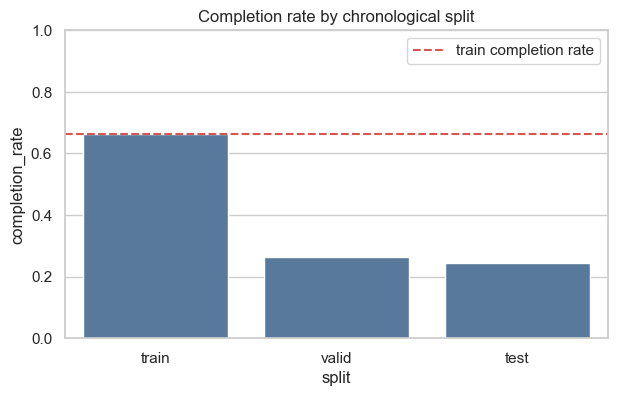

,year,rows,completed_days,completion_rate,visibility_available_share
0,2017,2,0,0.000000,0.00
1,2018,109,73,0.669725,0.00
2,2019,18,9,0.500000,0.00
3,2020,135,82,0.607407,0.00
4,2021,204,168,0.823529,0.75
5,2022,96,31,0.322917,1.00
6,2023,82,20,0.243902,1.00
7,2024,54,6,0.111111,1.00
8,2025,41,11,0.268293,1.00
9,2026,20,11,0.550000,1.00


,split,rows,completion_rate,visibility_available_share,date_from,date_to
0,train,532,0.663534,0.407895,2017-12-13,2022-07-01
1,valid,114,0.263158,1.000000,2022-07-06,2023-12-30
2,test,115,0.243478,1.000000,2024-01-10,2026-05-26


In [6]:
drift_summary = split_summary.copy()
drift_summary["cancelled_rate"] = 1 - drift_summary["completion_rate"]
drift_summary["completion_rate_delta_vs_train"] = (
    drift_summary["completion_rate"] - drift_summary.loc[drift_summary["split"] == "train", "completion_rate"].iloc[0]
)

display(
    drift_summary[
        [
            "split",
            "rows",
            "date_from",
            "date_to",
            "completed_days",
            "cancelled_days",
            "completion_rate",
            "cancelled_rate",
            "completion_rate_delta_vs_train",
        ]
    ]
)

fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(data=drift_summary, x="split", y="completion_rate", ax=ax, color="#4c78a8")
ax.axhline(y_train.mean(), color="#d9534f", linestyle="--", label="train completion rate")
ax.set_ylim(0, 1)
ax.set_title("Completion rate by chronological split")
ax.set_ylabel("completion_rate")
ax.legend()
plt.show()

yearly_summary = (
    df.assign(year=df["date"].dt.year)
    .groupby("year")
    .agg(
        rows=(target, "size"),
        completed_days=(target, "sum"),
        completion_rate=(target, "mean"),
        visibility_available_share=("mendeleyevo_visibility_min", lambda s: s.notna().mean()),
    )
    .reset_index()
)

display(yearly_summary)

visibility_coverage = (
    df.assign(split=split_labels, visibility_available=df["mendeleyevo_visibility_min"].notna())
    .groupby("split", sort=False)
    .agg(
        rows=(target, "size"),
        completion_rate=(target, "mean"),
        visibility_available_share=("visibility_available", "mean"),
        date_from=("date", "min"),
        date_to=("date", "max"),
    )
    .reset_index()
)

display(visibility_coverage)


## 2. Анализ данных

Смотрим распределение целевой переменной, сезонность, связь fog-risk с фактом рейса и видимость в Менделеево. Для задачи это особенно важно: отмены на Кунашире часто связаны с туманом и низкой облачностью.

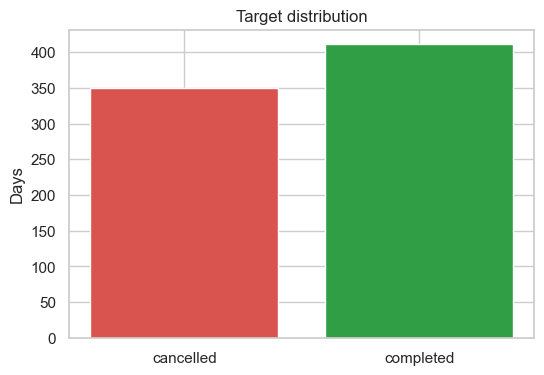

In [7]:
fig, ax = plt.subplots(figsize=(6, 4))
counts = df[target].value_counts().sort_index()
ax.bar(["cancelled", "completed"], [counts.get(0, 0), counts.get(1, 0)], color=["#d9534f", "#2f9e44"])
ax.set_title("Target distribution")
ax.set_ylabel("Days")
plt.show()

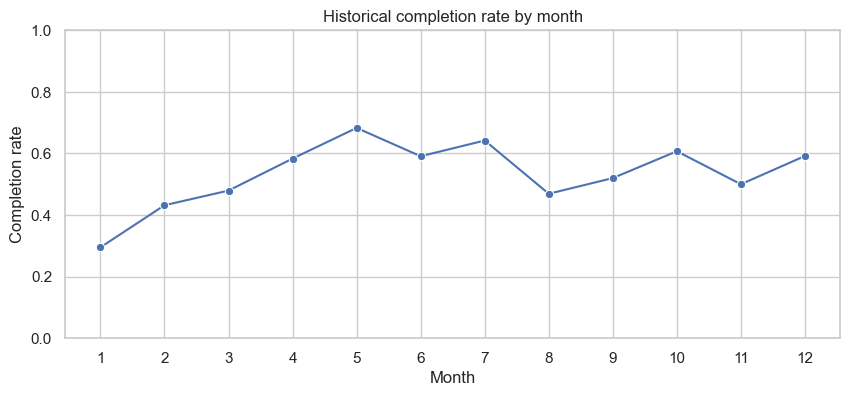

,month_num,days,completion_rate
0,1,61,0.295082
1,2,44,0.431818
2,3,73,0.479452
3,4,84,0.583333
4,5,82,0.682927
5,6,88,0.590909
6,7,81,0.641975
7,8,81,0.469136
8,9,50,0.520000
9,10,28,0.607143


In [8]:
monthly = (
    df.assign(month_num=df["date"].dt.month)
    .groupby("month_num")
    .agg(days=(target, "size"), completion_rate=(target, "mean"))
    .reset_index()
)

fig, ax = plt.subplots(figsize=(10, 4))
sns.lineplot(data=monthly, x="month_num", y="completion_rate", marker="o", ax=ax)
ax.set_title("Historical completion rate by month")
ax.set_xlabel("Month")
ax.set_ylabel("Completion rate")
ax.set_xticks(range(1, 13))
ax.set_ylim(0, 1)
plt.show()

monthly

,mendeleyevo_fog_low_cloud_risk_level,days,completion_rate
0,low,301,0.704319
1,medium,167,0.502994
2,high,293,0.392491


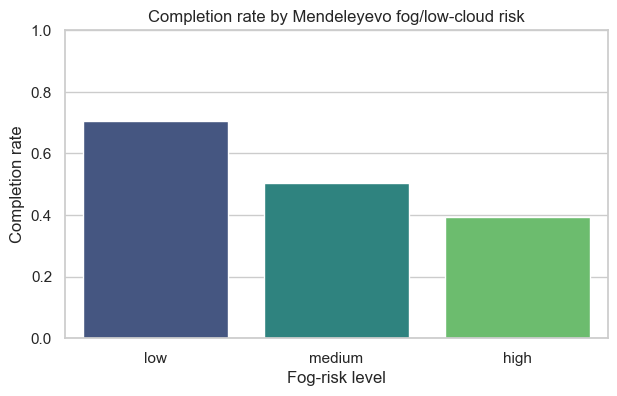

In [9]:
fog_col = "mendeleyevo_fog_low_cloud_risk_level"
if fog_col in df.columns:
    fog_summary = (
        df.dropna(subset=[fog_col])
        .groupby(fog_col)
        .agg(days=(target, "size"), completion_rate=(target, "mean"))
        .reindex(["low", "medium", "high"])
        .reset_index()
    )
    display(fog_summary)

    fig, ax = plt.subplots(figsize=(7, 4))
    sns.barplot(data=fog_summary, x=fog_col, y="completion_rate", ax=ax, palette="viridis")
    ax.set_title("Completion rate by Mendeleyevo fog/low-cloud risk")
    ax.set_xlabel("Fog-risk level")
    ax.set_ylabel("Completion rate")
    ax.set_ylim(0, 1)
    plt.show()

,visibility_bucket,days,completion_rate
0,<=1 km,290,0.396552
1,1-3 km,44,0.431818
2,3-6 km,18,0.333333
3,6-10 km,29,0.724138
4,>10 km,65,0.707692


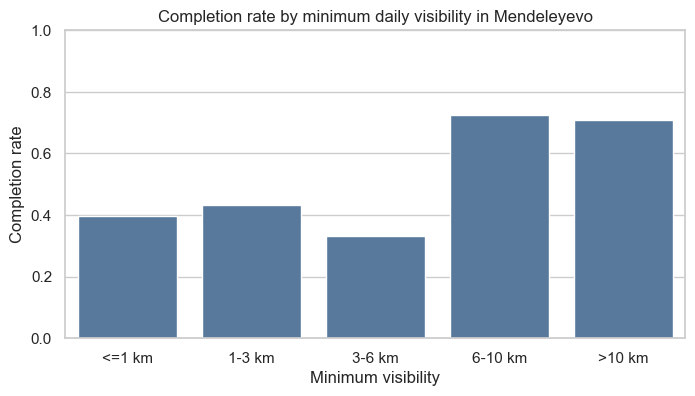

In [10]:
visibility_col = "mendeleyevo_visibility_min"
if visibility_col in df.columns:
    visibility_df = df.dropna(subset=[visibility_col]).copy()
    visibility_df["visibility_bucket"] = pd.cut(
        visibility_df[visibility_col],
        bins=[-np.inf, 1000, 3000, 6000, 10000, np.inf],
        labels=["<=1 km", "1-3 km", "3-6 km", "6-10 km", ">10 km"],
    )
    visibility_summary = (
        visibility_df.groupby("visibility_bucket", observed=True)
        .agg(days=(target, "size"), completion_rate=(target, "mean"))
        .reset_index()
    )
    display(visibility_summary)

    fig, ax = plt.subplots(figsize=(8, 4))
    sns.barplot(data=visibility_summary, x="visibility_bucket", y="completion_rate", ax=ax, color="#4c78a8")
    ax.set_title("Completion rate by minimum daily visibility in Mendeleyevo")
    ax.set_xlabel("Minimum visibility")
    ax.set_ylabel("Completion rate")
    ax.set_ylim(0, 1)
    plt.show()

In [11]:
numeric_for_corr = df.select_dtypes(include=[np.number]).copy()
correlations = (
    numeric_for_corr.corr(numeric_only=True)[target]
    .drop(labels=[target], errors="ignore")
    .dropna()
    .sort_values(key=lambda s: s.abs(), ascending=False)
    .head(20)
    .rename("corr_with_completed")
    .to_frame()
)
correlations

,corr_with_completed
prev_14_completed_rate,0.475785
prev_7_cancelled_count,-0.464942
prev_30_completed_rate,0.464260
prev_3_cancelled_count,-0.421724
completed_streak_before,0.306776
prev_1_completed,0.305907
mendeleyevo_fog_low_cloud_risk_score,-0.292357
year,-0.291459
cancelled_streak_before,-0.281134
mendeleyevo_visibility_mean,0.261130


## 3. Модели

Сравниваем четыре подхода:

- `Production heuristic baseline` - backtest-версия текущей формулы `mvp-baseline-002`, которая уже работает в сервисе.
- `LogisticRegression` - простая линейная ML-модель с балансировкой классов.
- `DecisionTreeClassifier(max_depth=3)` - простая интерпретируемая нелинейная модель.
- `RandomForestClassifier` - усложненная ML-модель с подбором гиперпараметров через `GridSearchCV` и `TimeSeriesSplit`.

Важно: production baseline в backtest-режиме для каждой исторической даты использует только факты прошлых дат, чтобы не подглядывать в будущее. Погодная поправка считается по историческим погодным признакам выбранного дня как прокси того погодного слоя, который production получает через Open-Meteo для будущей даты.

In [12]:
cat_cols = X_train.select_dtypes(include=["object", "category"]).columns.tolist()
num_cols = [col for col in X_train.columns if col not in cat_cols]

numeric_pipe = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

categorical_pipe = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
    ]
)

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_pipe, num_cols),
        ("cat", categorical_pipe, cat_cols),
    ]
)

print(f"Numeric features: {len(num_cols)}")
print(f"Categorical features: {len(cat_cols)}")

Numeric features: 97
Categorical features: 3


In [13]:
def evaluate_predictions(name, split, y_part, pred, proba):
    cancelled_true = 1 - y_part
    cancelled_pred = 1 - pred

    return {
        "model": name,
        "split": split,
        "accuracy": accuracy_score(y_part, pred),
        "balanced_accuracy": balanced_accuracy_score(y_part, pred),
        "roc_auc": roc_auc_score(y_part, proba),
        "brier_score": brier_score_loss(y_part, proba),
        "f1_cancelled": f1_score(cancelled_true, cancelled_pred, zero_division=0),
        "precision_cancelled": precision_score(cancelled_true, cancelled_pred, zero_division=0),
        "recall_cancelled": recall_score(cancelled_true, cancelled_pred, zero_division=0),
        "f1_completed": f1_score(y_part, pred, zero_division=0),
        "precision_completed": precision_score(y_part, pred, zero_division=0),
        "recall_completed": recall_score(y_part, pred, zero_division=0),
        "support_cancelled": int(cancelled_true.sum()),
        "support_completed": int(y_part.sum()),
    }


def predict_completed_probability(model, X_part):
    proba = model.predict_proba(X_part)
    classes = list(model.classes_) if hasattr(model, "classes_") else list(model.named_steps["model"].classes_)
    return proba[:, classes.index(1)]


def evaluate_model(name, split, model, X_part, y_part):
    pred = model.predict(X_part)
    proba = predict_completed_probability(model, X_part)
    return evaluate_predictions(name, split, y_part, pred, proba)


def add_quality_score(metrics_df):
    result = metrics_df.copy()
    result["quality_score"] = (
        0.30 * result["roc_auc"]
        + 0.25 * result["balanced_accuracy"]
        + 0.15 * result["f1_cancelled"]
        + 0.15 * result["f1_completed"]
        + 0.15 * (1 - result["brier_score"])
    )
    return result


def safe_probability(completed, total, fallback=0.5):
    if total <= 0:
        return fallback
    return round((completed + 1) / (total + 2), 4)


def circular_distance(day_a, day_b):
    raw = abs(day_a - day_b)
    return min(raw, 366 - raw)


def production_history_probability(target_date, history_df):
    past = history_df[history_df["date"] < target_date]
    if past.empty:
        return 0.5, None, None

    month_rows = past[past["date"].dt.month == target_date.month]
    decade = (target_date.day - 1) // 10 + 1
    decade_rows = past[
        (past["date"].dt.month == target_date.month)
        & (((past["date"].dt.day - 1) // 10 + 1) == decade)
    ]

    target_doy = target_date.timetuple().tm_yday
    similar_rows = past[
        past["date"].dt.dayofyear.apply(lambda day: circular_distance(int(day), target_doy) <= 14)
    ]
    if len(similar_rows) < 10:
        similar_rows = month_rows

    historical_probability = safe_probability(int(similar_rows[target].sum()), len(similar_rows))
    month_probability = (
        safe_probability(int(month_rows[target].sum()), len(month_rows))
        if len(month_rows)
        else None
    )
    decade_probability = (
        safe_probability(int(decade_rows[target].sum()), len(decade_rows))
        if len(decade_rows)
        else None
    )
    return historical_probability, month_probability, decade_probability


def optional_float(row, column):
    value = row.get(column, np.nan)
    return None if pd.isna(value) else float(value)


def production_weather_adjustment(row):
    adjustment = 0.0

    wind_speed = optional_float(row, "mendeleyevo_wind_speed_10m_mean")
    wind_gusts = optional_float(row, "mendeleyevo_wind_gusts_10m_max")
    humidity = optional_float(row, "mendeleyevo_relative_humidity_2m_mean")
    cloud_cover = optional_float(row, "mendeleyevo_cloud_cover_mean")
    cloud_cover_low = optional_float(row, "mendeleyevo_cloud_cover_low_mean")
    visibility = optional_float(row, "mendeleyevo_visibility_min")
    dew_point_spread = optional_float(row, "mendeleyevo_dew_point_spread_mean")
    precipitation = optional_float(row, "mendeleyevo_precipitation_sum")
    fog_risk_level = row.get("mendeleyevo_fog_low_cloud_risk_level")

    if wind_speed is not None and wind_speed >= 12:
        adjustment -= 0.05
    if wind_gusts is not None and wind_gusts >= 18:
        adjustment -= 0.07
    if humidity is not None and humidity >= 92:
        adjustment -= 0.04
    if cloud_cover is not None and cloud_cover >= 85:
        adjustment -= 0.03
    if cloud_cover_low is not None and cloud_cover_low >= 80:
        adjustment -= 0.05
    if visibility is not None and visibility <= 3000:
        adjustment -= 0.06
    if dew_point_spread is not None and dew_point_spread <= 2:
        adjustment -= 0.04
    if fog_risk_level == "medium":
        adjustment -= 0.04
    elif fog_risk_level == "high":
        adjustment -= 0.09
    if precipitation is not None and precipitation >= 3:
        adjustment -= 0.03

    return adjustment


def production_baseline_predict(rows, full_history_df, horizon_days=0):
    probabilities = []
    predictions = []

    for _, row in rows.iterrows():
        historical_probability, _, decade_probability = production_history_probability(row["date"], full_history_df)
        probability = historical_probability

        if decade_probability is not None:
            probability = 0.65 * historical_probability + 0.35 * decade_probability

        if horizon_days <= 15:
            probability += production_weather_adjustment(row)

        probability = round(min(max(probability, 0.05), 0.95), 4)
        threshold = 0.55 if horizon_days <= 10 else (0.45 if horizon_days <= 46 else 0.30)

        probabilities.append(probability)
        predictions.append(1 if probability >= threshold else 0)

    return np.array(predictions), np.array(probabilities)


In [14]:
rows = []
fitted_models = {}
prediction_store = {}


def record_predictions(name, split, y_part, pred, proba):
    prediction_store[(name, split)] = {
        "y": np.asarray(y_part),
        "pred": np.asarray(pred),
        "proba": np.asarray(proba),
    }
    rows.append(evaluate_predictions(name, split, y_part, pred, proba))


prod_valid_pred, prod_valid_proba = production_baseline_predict(
    df.iloc[train_end:valid_end],
    df,
    horizon_days=0,
)
prod_test_pred, prod_test_proba = production_baseline_predict(
    df.iloc[valid_end:],
    df,
    horizon_days=0,
)

record_predictions(
    "Production heuristic baseline",
    "valid",
    y_valid,
    prod_valid_pred,
    prod_valid_proba,
)
record_predictions(
    "Production heuristic baseline",
    "test",
    y_test,
    prod_test_pred,
    prod_test_proba,
)

models = {
    "Logistic Regression": Pipeline(
        steps=[
            ("prep", preprocess),
            ("model", LogisticRegression(max_iter=2000, class_weight="balanced", solver="liblinear")),
        ]
    ),
    "Decision Tree shallow": Pipeline(
        steps=[
            ("prep", preprocess),
            ("model", DecisionTreeClassifier(max_depth=3, min_samples_leaf=20, class_weight="balanced", random_state=42)),
        ]
    ),
}

for name, model in models.items():
    model.fit(X_train, y_train)
    fitted_models[name] = model

    valid_pred = model.predict(X_valid)
    valid_proba = predict_completed_probability(model, X_valid)
    record_predictions(name, "valid", y_valid, valid_pred, valid_proba)

    test_pred = model.predict(X_test)
    test_proba = predict_completed_probability(model, X_test)
    record_predictions(name, "test", y_test, test_pred, test_proba)

rf_pipe = Pipeline(
    steps=[
        ("prep", preprocess),
        ("model", RandomForestClassifier(random_state=42, class_weight="balanced_subsample", n_jobs=-1)),
    ]
)

param_grid = {
    "model__n_estimators": [200, 400],
    "model__max_depth": [4, 8, None],
    "model__min_samples_leaf": [5, 15, 30],
}

search = GridSearchCV(
    rf_pipe,
    param_grid=param_grid,
    scoring="balanced_accuracy",
    cv=TimeSeriesSplit(n_splits=4),
    n_jobs=-1,
)
search.fit(X_train, y_train)

fitted_models["RandomForest tuned"] = search.best_estimator_
rf_valid_pred = search.best_estimator_.predict(X_valid)
rf_valid_proba = predict_completed_probability(search.best_estimator_, X_valid)
record_predictions("RandomForest tuned", "valid", y_valid, rf_valid_pred, rf_valid_proba)

rf_test_pred = search.best_estimator_.predict(X_test)
rf_test_proba = predict_completed_probability(search.best_estimator_, X_test)
record_predictions("RandomForest tuned", "test", y_test, rf_test_pred, rf_test_proba)

print("Best RandomForest params:", search.best_params_)


Best RandomForest params: {'model__max_depth': 4, 'model__min_samples_leaf': 15, 'model__n_estimators': 200}


## 4. Метрики качества и анализ результатов

Используем несколько метрик:

- `accuracy` - общая доля верных ответов, но при дисбалансе классов ее нельзя читать отдельно.
- `balanced_accuracy` - точность с учетом дисбаланса классов.
- `roc_auc` - качество ранжирования вероятностей.
- `brier_score` - качество вероятностного прогноза, чем меньше, тем лучше.
- `f1_cancelled`, `precision_cancelled`, `recall_cancelled` - отдельно смотрим класс отмен, потому что для пользователя ошибка по отмене особенно болезненна.
- `f1_completed`, `precision_completed`, `recall_completed` - отдельно смотрим способность модели не сваливаться в постоянное предсказание отмены.

Совокупная метрика `quality_score` - учебная агрегированная оценка, в которой явно учитываются оба класса:

```text
0.30 * ROC-AUC
+ 0.25 * balanced_accuracy
+ 0.15 * F1(cancelled)
+ 0.15 * F1(completed)
+ 0.15 * (1 - Brier Score)
```

Она не заменяет отдельные метрики. Победителя выбираем только по `valid`; `test` не участвует в выборе модели и используется только для финальной оценки и диагностик выбранных по validation вариантов.


In [15]:
metrics = add_quality_score(pd.DataFrame(rows))
metrics_rounded = metrics.copy()
metric_cols = [col for col in metrics_rounded.columns if col not in ["model", "split"]]
metrics_rounded[metric_cols] = metrics_rounded[metric_cols].round(4)

split_order = {"valid": 0, "test": 1}
metrics_display = (
    metrics_rounded.assign(_split_order=metrics_rounded["split"].map(split_order))
    .sort_values(["_split_order", "quality_score"], ascending=[True, False])
    .drop(columns="_split_order")
)
metrics_display


,model,split,accuracy,balanced_accuracy,roc_auc,brier_score,f1_cancelled,precision_cancelled,recall_cancelled,f1_completed,precision_completed,recall_completed,support_cancelled,support_completed,quality_score
6,RandomForest tuned,valid,0.7456,0.5488,0.6421,0.1984,0.8482,0.7570,0.9643,0.2162,0.5714,0.1333,84,30,0.6097
4,Decision Tree shallow,valid,0.5702,0.5798,0.5968,0.2242,0.6573,0.7966,0.5595,0.4235,0.3273,0.6000,84,30,0.6025
0,Production heuristic baseline,valid,0.7368,0.5429,0.6034,0.1952,0.8421,0.7547,0.9524,0.2105,0.5000,0.1333,84,30,0.5953
2,Logistic Regression,valid,0.5877,0.4952,0.5119,0.2814,0.7117,0.7342,0.6905,0.2769,0.2571,0.3000,84,30,0.5335
7,RandomForest tuned,test,0.7826,0.6020,0.6864,0.1803,0.8691,0.7981,0.9540,0.3590,0.6364,0.2500,87,28,0.6636
1,Production heuristic baseline,test,0.7565,0.5121,0.7660,0.1536,0.8600,0.7611,0.9885,0.0667,0.5000,0.0357,87,28,0.6238
3,Logistic Regression,test,0.5739,0.5489,0.4984,0.3279,0.6797,0.7879,0.5977,0.3636,0.2857,0.5000,87,28,0.5440
5,Decision Tree shallow,test,0.5652,0.4583,0.5234,0.2260,0.6988,0.7342,0.6667,0.2188,0.1944,0.2500,87,28,0.5253


Selected model by validation quality_score: RandomForest tuned
Final test classification report for the validation-selected model:
              precision    recall  f1-score   support

   cancelled       0.80      0.95      0.87        87
   completed       0.64      0.25      0.36        28

    accuracy                           0.78       115
   macro avg       0.72      0.60      0.61       115
weighted avg       0.76      0.78      0.74       115



,model,split,accuracy,balanced_accuracy,roc_auc,brier_score,f1_cancelled,precision_cancelled,recall_cancelled,f1_completed,precision_completed,recall_completed,support_cancelled,support_completed,quality_score
7,RandomForest tuned,test,0.7826,0.602,0.6864,0.1803,0.8691,0.7981,0.954,0.359,0.6364,0.25,87,28,0.6636


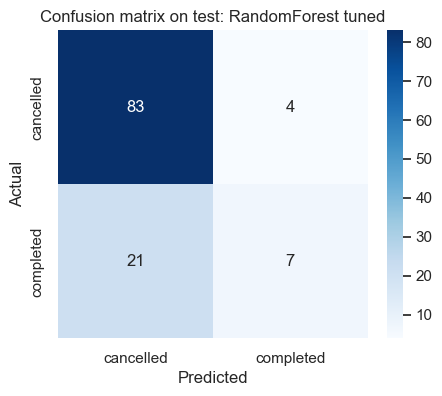

Production heuristic baseline diagnostic on test:
              precision    recall  f1-score   support

   cancelled       0.76      0.99      0.86        87
   completed       0.50      0.04      0.07        28

    accuracy                           0.76       115
   macro avg       0.63      0.51      0.46       115
weighted avg       0.70      0.76      0.67       115



In [16]:
best_valid_name = (
    metrics[metrics["split"] == "valid"]
    .sort_values("quality_score", ascending=False)
    .iloc[0]["model"]
)

selected_test = prediction_store[(best_valid_name, "test")]
selected_test_metrics = metrics[
    (metrics["split"] == "test") & (metrics["model"] == best_valid_name)
].copy()

print("Selected model by validation quality_score:", best_valid_name)
print("Final test classification report for the validation-selected model:")
print(
    classification_report(
        selected_test["y"],
        selected_test["pred"],
        target_names=["cancelled", "completed"],
        zero_division=0,
    )
)

display(selected_test_metrics.round(4))

cm = confusion_matrix(selected_test["y"], selected_test["pred"])
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["cancelled", "completed"],
    yticklabels=["cancelled", "completed"],
    ax=ax,
)
ax.set_title(f"Confusion matrix on test: {best_valid_name}")
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
plt.show()

baseline_test = prediction_store[("Production heuristic baseline", "test")]
print("Production heuristic baseline diagnostic on test:")
print(
    classification_report(
        baseline_test["y"],
        baseline_test["pred"],
        target_names=["cancelled", "completed"],
        zero_division=0,
    )
)


### Калибровка вероятностей

После выбора модели смотрим калибровку вероятностей на test. Это диагностический график: он не участвует в выборе победителя, но помогает понять, насколько вероятности можно использовать как риск-оценку.


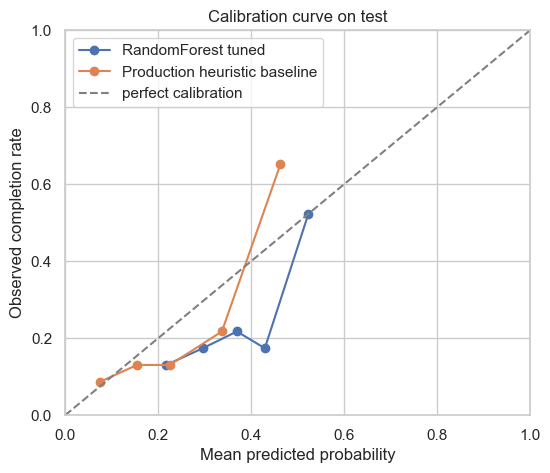

In [17]:
calibration_models = list(dict.fromkeys([best_valid_name, "Production heuristic baseline", "RandomForest tuned"]))
fig, ax = plt.subplots(figsize=(6, 5))

for model_name in calibration_models:
    if (model_name, "test") not in prediction_store:
        continue
    stored = prediction_store[(model_name, "test")]
    prob_true, prob_pred = calibration_curve(
        stored["y"],
        stored["proba"],
        n_bins=5,
        strategy="quantile",
    )
    ax.plot(prob_pred, prob_true, marker="o", label=model_name)

ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="perfect calibration")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_xlabel("Mean predicted probability")
ax.set_ylabel("Observed completion rate")
ax.set_title("Calibration curve on test")
ax.legend()
plt.show()


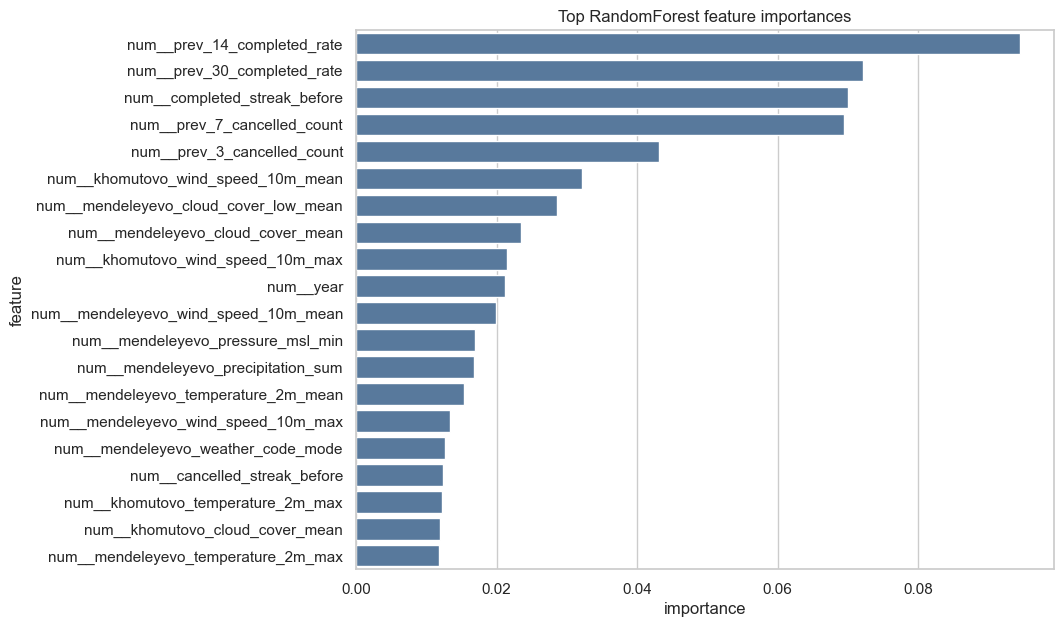

,feature,importance
86,num__prev_14_completed_rate,0.094550
87,num__prev_30_completed_rate,0.072169
92,num__completed_streak_before,0.069991
85,num__prev_7_cancelled_count,0.069459
84,num__prev_3_cancelled_count,0.043176
21,num__khomutovo_wind_speed_10m_mean,0.032101
51,num__mendeleyevo_cloud_cover_low_mean,0.028523
49,num__mendeleyevo_cloud_cover_mean,0.023401
22,num__khomutovo_wind_speed_10m_max,0.021507
0,num__year,0.021205


In [18]:
rf_model = fitted_models.get("RandomForest tuned")
if rf_model is not None:
    feature_names = rf_model.named_steps["prep"].get_feature_names_out()
    importances = rf_model.named_steps["model"].feature_importances_
    importance_df = (
        pd.DataFrame({"feature": feature_names, "importance": importances})
        .sort_values("importance", ascending=False)
        .head(20)
    )

    fig, ax = plt.subplots(figsize=(9, 7))
    sns.barplot(data=importance_df, x="importance", y="feature", ax=ax, color="#4c78a8")
    ax.set_title("Top RandomForest feature importances")
    plt.show()

    display(importance_df)

### Проверка влияния года и пропусков видимости

Проверяем, насколько `RandomForest tuned` зависит от `year` и missing-флагов видимости. Это sanity-check для признаков, которые могут кодировать не только погодные условия, но и исторический период данных.


In [19]:
def make_preprocessor(X_fit):
    cat_cols_local = X_fit.select_dtypes(include=["object", "category"]).columns.tolist()
    num_cols_local = [col for col in X_fit.columns if col not in cat_cols_local]

    numeric_pipe_local = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
        ]
    )
    categorical_pipe_local = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
        ]
    )

    return ColumnTransformer(
        transformers=[
            ("num", numeric_pipe_local, num_cols_local),
            ("cat", categorical_pipe_local, cat_cols_local),
        ]
    )


variant_prediction_store = {}


def evaluate_rf_variant(variant_name, drop_cols):
    drop_cols = [col for col in drop_cols if col in X_train.columns]
    X_train_variant = X_train.drop(columns=drop_cols)
    X_valid_variant = X_valid.drop(columns=drop_cols)
    X_test_variant = X_test.drop(columns=drop_cols)

    rf_params = {key.replace("model__", ""): value for key, value in search.best_params_.items()}
    model = Pipeline(
        steps=[
            ("prep", make_preprocessor(X_train_variant)),
            (
                "model",
                RandomForestClassifier(
                    random_state=42,
                    class_weight="balanced_subsample",
                    n_jobs=-1,
                    **rf_params,
                ),
            ),
        ]
    )
    model.fit(X_train_variant, y_train)

    variant_rows = []
    for split, X_part, y_part in [
        ("valid", X_valid_variant, y_valid),
        ("test", X_test_variant, y_test),
    ]:
        pred = model.predict(X_part)
        proba = predict_completed_probability(model, X_part)
        variant_prediction_store[(variant_name, split)] = {
            "y": np.asarray(y_part),
            "pred": np.asarray(pred),
            "proba": np.asarray(proba),
        }
        row = evaluate_predictions(variant_name, split, y_part, pred, proba)
        row["dropped_features"] = len(drop_cols)
        variant_rows.append(row)

    return variant_rows


visibility_missing_cols = [
    col for col in X_train.columns
    if "visibility" in col and col.endswith("_missing")
]
year_cols = [col for col in ["year"] if col in X_train.columns]

variant_specs = {
    "RF full feature set": [],
    "RF without year": year_cols,
    "RF without visibility missing flags": visibility_missing_cols,
    "RF without year + visibility missing flags": year_cols + visibility_missing_cols,
}

variant_rows = []
for variant_name, drop_cols in variant_specs.items():
    variant_rows.extend(evaluate_rf_variant(variant_name, drop_cols))

variant_metrics = add_quality_score(pd.DataFrame(variant_rows))
variant_metrics_rounded = variant_metrics.copy()
variant_metric_cols = [
    col for col in variant_metrics_rounded.columns
    if col not in ["model", "split"]
]
variant_metrics_rounded[variant_metric_cols] = variant_metrics_rounded[variant_metric_cols].round(4)
variant_metrics_rounded = (
    variant_metrics_rounded.assign(_split_order=variant_metrics_rounded["split"].map(split_order))
    .sort_values(["_split_order", "quality_score"], ascending=[True, False])
    .drop(columns="_split_order")
)
display(variant_metrics_rounded)

best_variant_name = (
    variant_metrics[variant_metrics["split"] == "valid"]
    .sort_values("quality_score", ascending=False)
    .iloc[0]["model"]
)
best_variant_test = variant_metrics[
    (variant_metrics["split"] == "test") & (variant_metrics["model"] == best_variant_name)
]

print("Best RF feature variant by validation quality_score:", best_variant_name)
display(best_variant_test.round(4))

stored_variant = variant_prediction_store[(best_variant_name, "test")]
print("Test classification report for the validation-selected RF feature variant:")
print(
    classification_report(
        stored_variant["y"],
        stored_variant["pred"],
        target_names=["cancelled", "completed"],
        zero_division=0,
    )
)


,model,split,accuracy,balanced_accuracy,roc_auc,brier_score,f1_cancelled,precision_cancelled,recall_cancelled,f1_completed,precision_completed,recall_completed,support_cancelled,support_completed,dropped_features,quality_score
2,RF without year,valid,0.7456,0.5917,0.6536,0.1996,0.8415,0.7778,0.9167,0.3556,0.5333,0.2667,84,30,1,0.6436
6,RF without year + visibility missing flags,valid,0.7456,0.5702,0.6401,0.2002,0.8449,0.7670,0.9405,0.2927,0.5455,0.2000,84,30,5,0.6252
4,RF without visibility missing flags,valid,0.7368,0.5536,0.6278,0.1981,0.8404,0.7596,0.9405,0.2500,0.5000,0.1667,84,30,4,0.6106
0,RF full feature set,valid,0.7456,0.5488,0.6421,0.1984,0.8482,0.7570,0.9643,0.2162,0.5714,0.1333,84,30,0,0.6097
3,RF without year,test,0.7913,0.6320,0.6823,0.1828,0.8723,0.8119,0.9425,0.4286,0.6429,0.3214,87,28,1,0.6804
5,RF without visibility missing flags,test,0.8000,0.6256,0.6905,0.1784,0.8796,0.8077,0.9655,0.4103,0.7273,0.2857,87,28,4,0.6803
7,RF without year + visibility missing flags,test,0.7826,0.6141,0.6790,0.1843,0.8677,0.8039,0.9425,0.3902,0.6154,0.2857,87,28,5,0.6683
1,RF full feature set,test,0.7826,0.6020,0.6864,0.1803,0.8691,0.7981,0.9540,0.3590,0.6364,0.2500,87,28,0,0.6636


Best RF feature variant by validation quality_score: RF without year


,model,split,accuracy,balanced_accuracy,roc_auc,brier_score,f1_cancelled,precision_cancelled,recall_cancelled,f1_completed,precision_completed,recall_completed,support_cancelled,support_completed,dropped_features,quality_score
3,RF without year,test,0.7913,0.632,0.6823,0.1828,0.8723,0.8119,0.9425,0.4286,0.6429,0.3214,87,28,1,0.6804


Test classification report for the validation-selected RF feature variant:
              precision    recall  f1-score   support

   cancelled       0.81      0.94      0.87        87
   completed       0.64      0.32      0.43        28

    accuracy                           0.79       115
   macro avg       0.73      0.63      0.65       115
weighted avg       0.77      0.79      0.76       115



## Выводы

Эксперимент сравнивает production-эвристику `mvp-baseline-002` и несколько ML-моделей на хронологическом разбиении данных. Основной выбор модели делается по `valid`; `test` используется для финальной оценки и диагностик, но не для выбора победителя.

Основные результаты:

- По основной метрике `quality_score` на validation лучший результат показывает `RandomForest tuned`: `quality_score=0.6097`. Следом идут `Decision Tree shallow` (`0.6025`) и production baseline (`0.5953`).
- На test выбранный `RandomForest tuned` показывает `accuracy=0.7826`, `balanced_accuracy=0.6020`, `roc_auc=0.6864`, `brier_score=0.1803`, `quality_score=0.6636`.
- RandomForest лучше baseline как бинарный классификатор, но остаётся консервативным: `recall_cancelled=0.9540`, а `recall_completed=0.2500`. То есть модель находит только четверть выполненных рейсов.
- Production baseline сильнее как вероятностная риск-эвристика: на test у него `roc_auc=0.7660` и `brier_score=0.1536`. Но в бинарном решении он почти всегда выбирает отмену: `recall_cancelled=0.9885`, `recall_completed=0.0357`, `balanced_accuracy=0.5121`.

Проверка признаков периода:

- В sensitivity-check лучший RF-вариант по validation - `RF without year`: `quality_score=0.6436` против `0.6097` у полного набора признаков.
- На test `RF without year` также выглядит лучше полного RF: `quality_score=0.6804`, `balanced_accuracy=0.6320`, `recall_completed=0.3214` против `0.6636`, `0.6020`, `0.2500` у full feature set.
- Вариант без missing-флагов видимости тоже не хуже полного RF на test (`quality_score=0.6803`). Значит, `year` и missing-флаги видимости не выглядят необходимыми для качества и могут работать как прокси периода данных.

Ограничения данных:

- В данных есть сильный target drift: completion rate равен `0.6635` на train, `0.2632` на valid и `0.2435` на test.
- Видимость доступна неравномерно: на train заполнено около `40.8%` строк, на valid и test - `100%`. Поэтому признаки видимости и missing-флаги могут частично отражать период данных, а не только погодные условия.
- Из-за такого drift абсолютные метрики нельзя интерпретировать как стабильное production-качество без дополнительной проверки причин изменения после 2022 года.

Итог:

> На текущем датасете production baseline остаётся сильной и понятной вероятностной эвристикой риска отмены. RandomForest даёт более полезное бинарное решение, но всё ещё слабо находит выполненные рейсы. Наиболее перспективный следующий кандидат по результатам проверки признаков - RF без `year`; его стоит дополнительно проверить вместе с вариантами без missing-флагов видимости, анализом target drift и калибровкой вероятностей.

Следующие шаги:

- Разобрать причину сдвига completion rate после 2022 года: реальные операционные изменения или изменение источников/разметки.
- Провести отдельную оценку на периодах до и после появления visibility-данных.
- Проверить RF без `year` и/или без missing-флагов видимости как отдельные production-кандидаты.
- Добавить калибровку вероятностей для ML-моделей и сравнить не только классификацию, но и decision policy при разных порогах.
- Проверять новые данные 2026 года как forward-monitoring, не включая их в подбор модели до фиксации протокола оценки.
